# 第七章：AlexNet - PyTorch 實作

## 論文：ImageNet Classification with Deep Convolutional Neural Networks
**作者**：Alex Krizhevsky, Ilya Sutskever, Geoffrey E. Hinton (2012)

本 notebook 實作 AlexNet 架構，展示深度卷積神經網路的關鍵技術。

In [1]:
# 跨平台中文字型設定（支援 Colab、VSCode、Antigravity 等本地環境）
import subprocess
import os
import shutil
import platform

system = platform.system()

# 必須在 import matplotlib 之前清除快取
cache_dir = os.path.expanduser('~/.matplotlib')
if os.path.exists(cache_dir):
    for f in os.listdir(cache_dir):
        if f.startswith('fontlist'):
            try:
                os.remove(os.path.join(cache_dir, f))
            except:
                pass

cache_dir2 = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(cache_dir2):
    shutil.rmtree(cache_dir2, ignore_errors=True)

# Linux/Colab 環境安裝中文字型
if system == 'Linux' or 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    try:
        result = subprocess.run(['fc-list', ':lang=zh'], capture_output=True, text=True)
        if 'Noto Sans CJK' not in result.stdout:
            print("正在安裝中文字型...")
            subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
            subprocess.run(['apt-get', 'install', '-qq', '-y', 'fonts-noto-cjk'], capture_output=True)
            print("中文字型安裝完成，請重新啟動 kernel")
    except:
        pass

print(f"✓ {system} 環境")

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# 重建字型快取並設定中文字型
from matplotlib.font_manager import fontManager
fontManager.__init__()

chinese_fonts = [
    'Heiti TC', 'PingFang TC', 'Noto Sans CJK TC',
    'Heiti SC', 'PingFang SC', 'Noto Sans CJK SC', 
    'Microsoft JhengHei', 'Microsoft YaHei',
    'SimHei', 'WenQuanYi Micro Hei', 'Arial Unicode MS',
]

available_fonts = set(f.name for f in fontManager.ttflist)
selected_font = None
for font in chinese_fonts:
    if font in available_fonts:
        selected_font = font
        break

if selected_font:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [selected_font] + chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✓ 使用中文字型: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = chinese_fonts
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠ 使用預設字型列表")

import warnings
warnings.filterwarnings('ignore')

# 執行跨平台字型設定
setup_chinese_font()

# 跨平台中文字型優先順序
chinese_fonts = [
    'Noto Sans CJK TC',      # Linux/Colab/Mac(安裝後) 繁體
    'Noto Sans CJK SC',      # Linux/Colab/Mac(安裝後) 簡體
    'Heiti TC',              # Mac 內建 繁體
    'Heiti SC',              # Mac 內建 簡體
    'PingFang TC',           # Mac 內建 繁體
    'PingFang SC',           # Mac 內建 簡體
    'Microsoft JhengHei',    # Windows 微軟正黑體 繁體
    'Microsoft YaHei',       # Windows 微軟雅黑 簡體
    'SimHei',                # Windows 黑體
    'WenQuanYi Micro Hei',   # Linux 文泉驛微米黑
    'Droid Sans Fallback',   # Android/舊版 Linux
    'Arial Unicode MS',      # 跨平台 Unicode 字型
    'DejaVu Sans',           # 後備字型
]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = chinese_fonts
plt.rcParams['axes.unicode_minus'] = False

# 驗證可用字型
from matplotlib.font_manager import FontManager
fm = FontManager()
available_fonts = set(f.name for f in fm.ttflist)
for font in chinese_fonts:
    if font in available_fonts:
        print(f"✓ 使用中文字型: {font}")
        break

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用裝置: {device}")

✓ Darwin 環境


Matplotlib is building the font cache; this may take a moment.


✓ 使用中文字型: Heiti TC
PyTorch 版本: 2.9.1
使用裝置: cpu


## 1. ReLU 活化函數

AlexNet 使用 ReLU 代替傳統的 Sigmoid/Tanh，大幅加速訓練。

$$f(x) = \max(0, x)$$

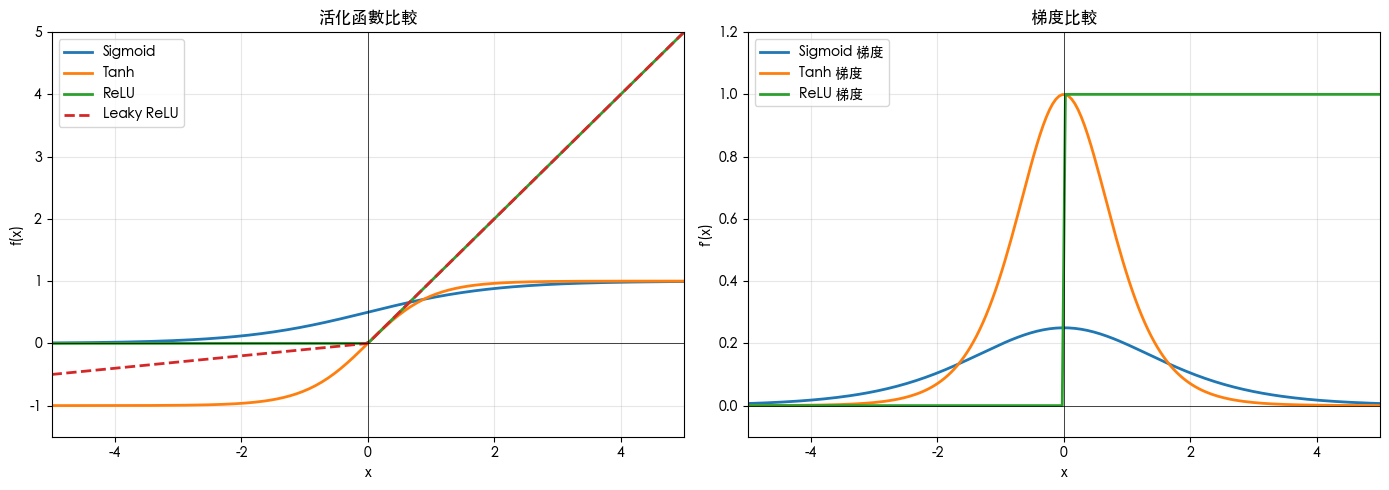

觀察：
1. Sigmoid/Tanh 在飽和區域梯度接近 0（梯度消失）
2. ReLU 在正數區域梯度恆為 1，不會飽和
3. ReLU 計算更簡單（只需比較），訓練更快


In [3]:
# 比較不同活化函數
x = torch.linspace(-5, 5, 200)

# 計算各活化函數
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
relu = torch.relu(x)
leaky_relu = F.leaky_relu(x, 0.1)

# 繪製比較圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 活化函數
ax = axes[0]
ax.plot(x.numpy(), sigmoid.numpy(), label='Sigmoid', linewidth=2)
ax.plot(x.numpy(), tanh.numpy(), label='Tanh', linewidth=2)
ax.plot(x.numpy(), relu.numpy(), label='ReLU', linewidth=2)
ax.plot(x.numpy(), leaky_relu.numpy(), label='Leaky ReLU', linewidth=2, linestyle='--')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('活化函數比較')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-1.5, 5)

# 梯度比較
ax = axes[1]
x_grad = x.clone().requires_grad_(True)

# Sigmoid 梯度
y = torch.sigmoid(x_grad)
grad_sigmoid = torch.autograd.grad(y.sum(), x_grad, create_graph=True)[0]

# Tanh 梯度
x_grad2 = x.clone().requires_grad_(True)
y = torch.tanh(x_grad2)
grad_tanh = torch.autograd.grad(y.sum(), x_grad2, create_graph=True)[0]

# ReLU 梯度（手動計算避免不連續點問題）
grad_relu = (x > 0).float()

ax.plot(x.numpy(), grad_sigmoid.detach().numpy(), label='Sigmoid 梯度', linewidth=2)
ax.plot(x.numpy(), grad_tanh.detach().numpy(), label='Tanh 梯度', linewidth=2)
ax.plot(x.numpy(), grad_relu.numpy(), label='ReLU 梯度', linewidth=2)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel("f'(x)")
ax.set_title('梯度比較')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.1, 1.2)

plt.tight_layout()
plt.show()

print("觀察：")
print("1. Sigmoid/Tanh 在飽和區域梯度接近 0（梯度消失）")
print("2. ReLU 在正數區域梯度恆為 1，不會飽和")
print("3. ReLU 計算更簡單（只需比較），訓練更快")

## 2. Dropout 正規化

Dropout 是 AlexNet 的重要創新，有效防止過擬合。

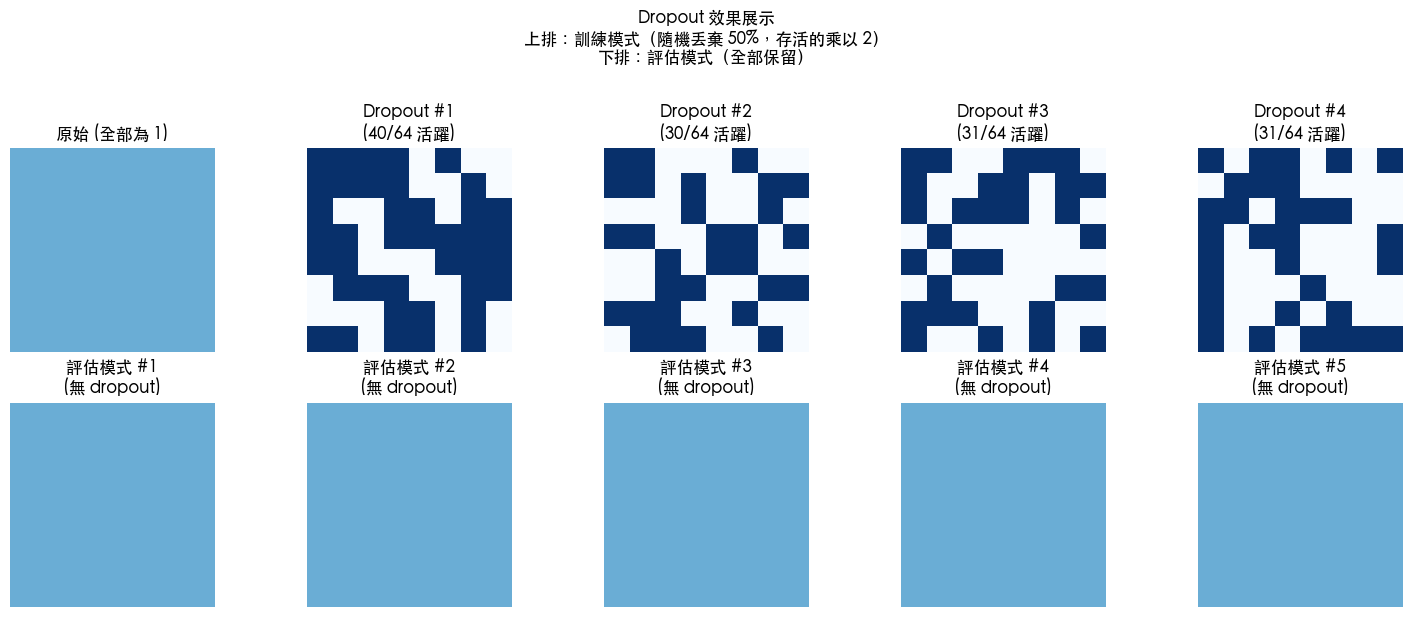

Dropout 原理：
- 訓練時：隨機將神經元輸出設為 0，存活的乘以 1/(1-p)
- 評估時：不進行 dropout，直接使用全部神經元
- 效果：防止神經元共適應，相當於訓練多個子網路的集成


In [4]:
class DropoutDemo(nn.Module):
    """展示 Dropout 的效果"""
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        return self.dropout(x)


# 視覺化 Dropout
dropout = DropoutDemo(0.5)

# 建立一個 8x8 的特徵圖
x = torch.ones(1, 1, 8, 8)

# 訓練模式下的多次 dropout
dropout.train()
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

axes[0, 0].imshow(x.squeeze().numpy(), cmap='Blues', vmin=0, vmax=2)
axes[0, 0].set_title('原始 (全部為 1)')
axes[0, 0].axis('off')

for i in range(1, 5):
    dropped = dropout(x.clone())
    axes[0, i].imshow(dropped.squeeze().numpy(), cmap='Blues', vmin=0, vmax=2)
    active = (dropped > 0).sum().item()
    axes[0, i].set_title(f'Dropout #{i}\n({active}/64 活躍)')
    axes[0, i].axis('off')

# 評估模式下（無 dropout）
dropout.eval()
for i in range(5):
    result = dropout(x.clone())
    axes[1, i].imshow(result.squeeze().numpy(), cmap='Blues', vmin=0, vmax=2)
    axes[1, i].set_title(f'評估模式 #{i+1}\n(無 dropout)')
    axes[1, i].axis('off')

plt.suptitle('Dropout 效果展示\n上排：訓練模式（隨機丟棄 50%，存活的乘以 2）\n下排：評估模式（全部保留）',
            fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Dropout 原理：")
print("- 訓練時：隨機將神經元輸出設為 0，存活的乘以 1/(1-p)")
print("- 評估時：不進行 dropout，直接使用全部神經元")
print("- 效果：防止神經元共適應，相當於訓練多個子網路的集成")

## 3. 卷積層運算

理解卷積的基本運算

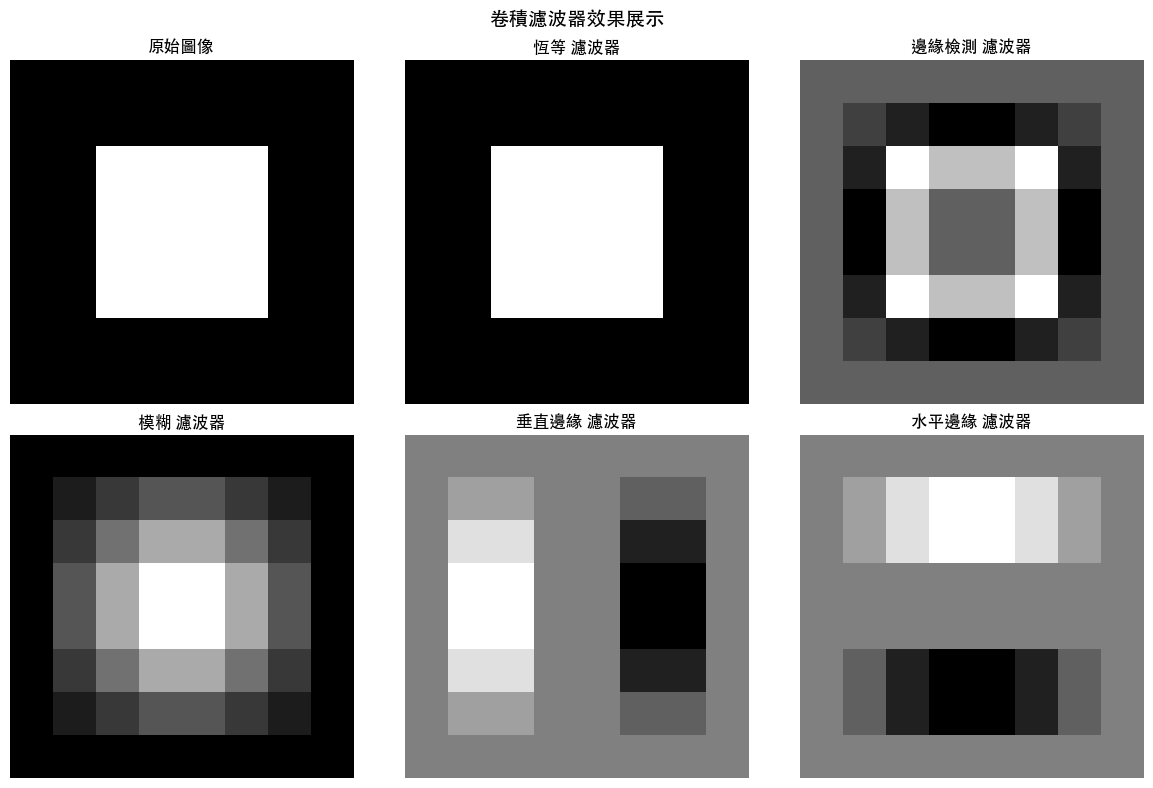

In [5]:
def visualize_convolution():
    """視覺化卷積運算過程"""
    # 建立一個簡單的輸入圖像（8x8）
    input_img = torch.zeros(1, 1, 8, 8)
    input_img[0, 0, 2:6, 2:6] = 1  # 中間一個方塊

    # 不同類型的濾波器
    filters = {
        '恆等': torch.tensor([[0, 0, 0], [0, 1, 0], [0, 0, 0]]).float(),
        '邊緣檢測': torch.tensor([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]).float(),
        '模糊': torch.ones(3, 3).float() / 9,
        '垂直邊緣': torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]).float(),
        '水平邊緣': torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]).float(),
    }

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    # 顯示原始圖像
    axes[0, 0].imshow(input_img.squeeze().numpy(), cmap='gray')
    axes[0, 0].set_title('原始圖像')
    axes[0, 0].axis('off')

    # 應用各濾波器
    for idx, (name, kernel) in enumerate(list(filters.items())[:5]):
        row = (idx + 1) // 3
        col = (idx + 1) % 3

        # 進行卷積
        kernel_4d = kernel.view(1, 1, 3, 3)
        output = F.conv2d(input_img, kernel_4d, padding=1)

        axes[row, col].imshow(output.squeeze().numpy(), cmap='gray')
        axes[row, col].set_title(f'{name} 濾波器')
        axes[row, col].axis('off')

    plt.suptitle('卷積濾波器效果展示', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_convolution()

In [6]:
# 展示卷積輸出尺寸計算
print("=" * 50)
print("卷積輸出尺寸計算公式：")
print("H_out = floor((H_in + 2*padding - kernel_size) / stride) + 1")
print("=" * 50)

# AlexNet 第一層卷積的尺寸變化
input_size = 227
kernel_size = 11
stride = 4
padding = 2

output_size = (input_size + 2*padding - kernel_size) // stride + 1
print(f"\nAlexNet Conv1:")
print(f"  輸入: {input_size}x{input_size}")
print(f"  核大小: {kernel_size}x{kernel_size}")
print(f"  步幅: {stride}")
print(f"  填充: {padding}")
print(f"  輸出: {output_size}x{output_size}")

# 池化後
pool_kernel = 3
pool_stride = 2
pooled_size = (output_size - pool_kernel) // pool_stride + 1
print(f"  MaxPool (3x3, stride=2) 後: {pooled_size}x{pooled_size}")

卷積輸出尺寸計算公式：
H_out = floor((H_in + 2*padding - kernel_size) / stride) + 1

AlexNet Conv1:
  輸入: 227x227
  核大小: 11x11
  步幅: 4
  填充: 2
  輸出: 56x56
  MaxPool (3x3, stride=2) 後: 27x27


## 4. AlexNet 完整架構

實作原版 AlexNet（適用於 224x224 或 227x227 圖像）

In [7]:
class AlexNet(nn.Module):
    """
    AlexNet 架構

    輸入: 3 x 224 x 224 (或 227 x 227)
    輸出: num_classes 維向量
    """
    def __init__(self, num_classes=1000):
        super(AlexNet, self).__init__()

        # 特徵提取層（5 個卷積層）
        self.features = nn.Sequential(
            # Conv1: 3 -> 96, 11x11, stride=4
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv2: 96 -> 256, 5x5
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Conv3: 256 -> 384, 3x3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 384 -> 384, 3x3
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 384 -> 256, 3x3
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # 自適應池化確保固定輸出
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        # 分類器（3 個全連接層）
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

        # 權重初始化
        self._initialize_weights()

    def _initialize_weights(self):
        """AlexNet 風格的權重初始化"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.constant_(m.bias, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# 建立模型並檢視結構
model = AlexNet(num_classes=1000)
print("AlexNet 架構：")
print("=" * 60)

# 計算參數數量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"總參數數量: {total_params:,}")
print(f"可訓練參數: {trainable_params:,}")

# 測試前向傳播
x = torch.randn(1, 3, 224, 224)
output = model(x)
print(f"\n輸入形狀: {x.shape}")
print(f"輸出形狀: {output.shape}")

AlexNet 架構：
總參數數量: 62,378,344
可訓練參數: 62,378,344

輸入形狀: torch.Size([1, 3, 224, 224])
輸出形狀: torch.Size([1, 1000])


In [8]:
# 追蹤每層的輸出形狀
def trace_shapes(model, input_tensor):
    """追蹤網路中每層的輸出形狀"""
    shapes = []
    x = input_tensor

    print(f"輸入: {x.shape}")
    print("-" * 50)

    # 特徵提取層
    for i, layer in enumerate(model.features):
        x = layer(x)
        layer_name = layer.__class__.__name__
        if hasattr(layer, 'kernel_size'):
            print(f"Layer {i:2d} ({layer_name:15s}): {x.shape}")
        elif 'ReLU' in layer_name:
            pass  # 跳過 ReLU 的輸出
        else:
            print(f"Layer {i:2d} ({layer_name:15s}): {x.shape}")

    # 自適應池化
    x = model.avgpool(x)
    print(f"AdaptiveAvgPool2d:       {x.shape}")

    # 展平
    x = torch.flatten(x, 1)
    print(f"Flatten:                 {x.shape}")

    # 分類器
    for i, layer in enumerate(model.classifier):
        x = layer(x)
        layer_name = layer.__class__.__name__
        if 'Linear' in layer_name or 'Dropout' in layer_name:
            print(f"Classifier {i} ({layer_name:10s}): {x.shape}")

    return x

print("\n" + "=" * 50)
print("AlexNet 各層輸出形狀追蹤")
print("=" * 50)

model.eval()
x = torch.randn(1, 3, 224, 224)
_ = trace_shapes(model, x)


AlexNet 各層輸出形狀追蹤
輸入: torch.Size([1, 3, 224, 224])
--------------------------------------------------
Layer  0 (Conv2d         ): torch.Size([1, 96, 55, 55])
Layer  2 (MaxPool2d      ): torch.Size([1, 96, 27, 27])
Layer  3 (Conv2d         ): torch.Size([1, 256, 27, 27])
Layer  5 (MaxPool2d      ): torch.Size([1, 256, 13, 13])
Layer  6 (Conv2d         ): torch.Size([1, 384, 13, 13])
Layer  8 (Conv2d         ): torch.Size([1, 384, 13, 13])
Layer 10 (Conv2d         ): torch.Size([1, 256, 13, 13])
Layer 12 (MaxPool2d      ): torch.Size([1, 256, 6, 6])
AdaptiveAvgPool2d:       torch.Size([1, 256, 6, 6])
Flatten:                 torch.Size([1, 9216])
Classifier 0 (Dropout   ): torch.Size([1, 9216])
Classifier 1 (Linear    ): torch.Size([1, 4096])
Classifier 3 (Dropout   ): torch.Size([1, 4096])
Classifier 4 (Linear    ): torch.Size([1, 4096])
Classifier 6 (Linear    ): torch.Size([1, 1000])


## 5. 簡化版 AlexNet（用於 CIFAR-10）

In [9]:
class AlexNetCIFAR(nn.Module):
    """
    適用於 CIFAR-10 (32x32) 的簡化 AlexNet
    """
    def __init__(self, num_classes=10):
        super(AlexNetCIFAR, self).__init__()

        self.features = nn.Sequential(
            # Conv1: 3 -> 64
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16

            # Conv2: 64 -> 192
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8

            # Conv3: 192 -> 384
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv4: 384 -> 256
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Conv5: 256 -> 256
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 4x4
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# 測試簡化版
model_cifar = AlexNetCIFAR(num_classes=10)
x_cifar = torch.randn(1, 3, 32, 32)
output_cifar = model_cifar(x_cifar)

print("AlexNet CIFAR 版本：")
print(f"輸入形狀: {x_cifar.shape}")
print(f"輸出形狀: {output_cifar.shape}")
print(f"參數數量: {sum(p.numel() for p in model_cifar.parameters()):,}")

AlexNet CIFAR 版本：
輸入形狀: torch.Size([1, 3, 32, 32])
輸出形狀: torch.Size([1, 10])
參數數量: 6,976,842


## 6. 合成圖像資料集

訓練集大小: 5000
測試集大小: 1000


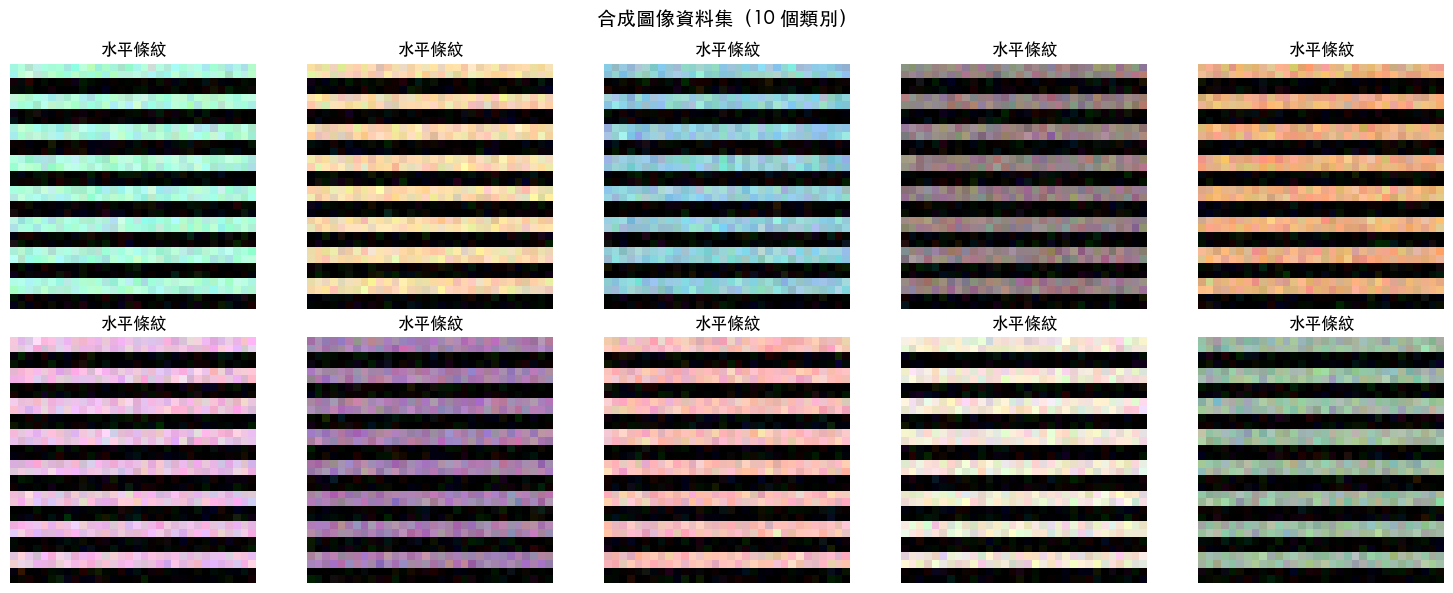

In [10]:
class SyntheticImageDataset(Dataset):
    """
    合成圖像資料集

    類別：
    0: 水平條紋
    1: 垂直條紋
    2: 對角線
    3: 棋盤格
    4: 圓形
    5: 方形
    6: 十字
    7: 三角形
    8: 隨機雜訊
    9: 漸層
    """
    def __init__(self, num_samples, image_size=32, seed=None):
        self.num_samples = num_samples
        self.image_size = image_size
        self.class_names = ['水平條紋', '垂直條紋', '對角線', '棋盤格', '圓形',
                           '方形', '十字', '三角形', '雜訊', '漸層']

        if seed is not None:
            np.random.seed(seed)

        self.data = []
        self.labels = []

        for i in range(num_samples):
            label = i % 10
            img = self._generate_image(label)
            self.data.append(img)
            self.labels.append(label)

    def _generate_image(self, class_label):
        """生成指定類別的圖像"""
        size = self.image_size
        img = np.zeros((3, size, size), dtype=np.float32)

        if class_label == 0:  # 水平條紋
            for row in range(0, size, 4):
                img[:, row:row+2, :] = 1

        elif class_label == 1:  # 垂直條紋
            for col in range(0, size, 4):
                img[:, :, col:col+2] = 1

        elif class_label == 2:  # 對角線
            for i in range(size):
                img[:, i, i] = 1
                if i+1 < size:
                    img[:, i, i+1] = 0.5

        elif class_label == 3:  # 棋盤格
            for i in range(0, size, 4):
                for j in range(0, size, 4):
                    if (i//4 + j//4) % 2 == 0:
                        img[:, i:i+4, j:j+4] = 1

        elif class_label == 4:  # 圓形
            center = size // 2
            radius = size // 3
            y, x = np.ogrid[:size, :size]
            mask = (x - center)**2 + (y - center)**2 <= radius**2
            img[:, mask] = 1

        elif class_label == 5:  # 方形
            margin = size // 4
            img[:, margin:-margin, margin:-margin] = 1

        elif class_label == 6:  # 十字
            mid = size // 2
            thickness = 3
            img[:, mid-thickness:mid+thickness, :] = 1
            img[:, :, mid-thickness:mid+thickness] = 1

        elif class_label == 7:  # 三角形
            for i in range(size):
                width = int((i / size) * size / 2)
                start = max(0, size // 2 - width)
                end = min(size, size // 2 + width + 1)
                img[:, i, start:end] = 1

        elif class_label == 8:  # 隨機雜訊
            img = np.random.rand(3, size, size).astype(np.float32)

        else:  # 漸層
            for i in range(size):
                img[:, i, :] = i / size

        # 添加顏色變化
        color = np.random.rand(3, 1, 1).astype(np.float32) * 0.5 + 0.5
        img = img * color

        # 添加輕微雜訊
        img += np.random.randn(3, size, size).astype(np.float32) * 0.05
        img = np.clip(img, 0, 1)

        return img

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), self.labels[idx]


# 建立資料集
train_dataset = SyntheticImageDataset(num_samples=5000, image_size=32, seed=42)
test_dataset = SyntheticImageDataset(num_samples=1000, image_size=32, seed=123)

print(f"訓練集大小: {len(train_dataset)}")
print(f"測試集大小: {len(test_dataset)}")

# 視覺化樣本
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(10):
    idx = i * (len(train_dataset) // 10)
    img, label = train_dataset[idx]
    img_np = img.numpy().transpose(1, 2, 0)  # CHW -> HWC

    row = i // 5
    col = i % 5
    axes[row, col].imshow(img_np)
    axes[row, col].set_title(train_dataset.class_names[label])
    axes[row, col].axis('off')

plt.suptitle('合成圖像資料集（10 個類別）', fontsize=14)
plt.tight_layout()
plt.show()

## 7. 資料增強

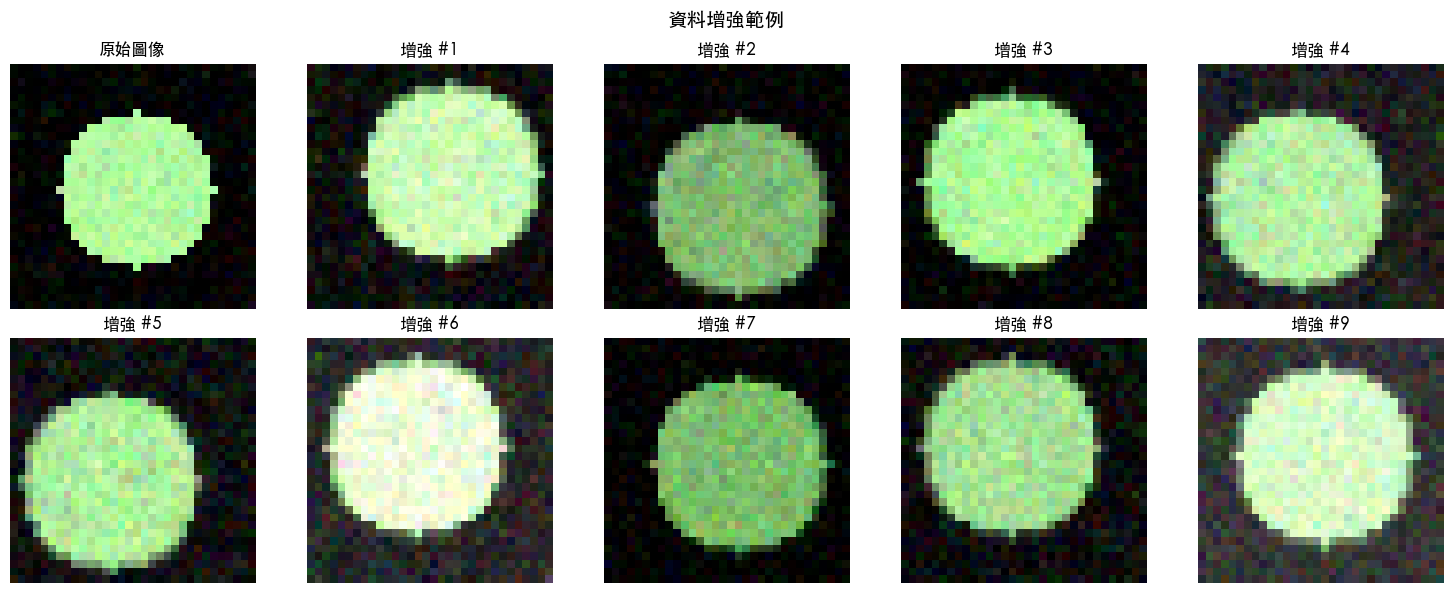

In [11]:
class DataAugmentation:
    """AlexNet 風格的資料增強"""

    @staticmethod
    def random_horizontal_flip(img, p=0.5):
        """隨機水平翻轉"""
        if np.random.rand() < p:
            return torch.flip(img, dims=[2])
        return img

    @staticmethod
    def random_crop(img, crop_size=28, target_size=32):
        """隨機裁剪並調整大小"""
        _, h, w = img.shape

        # 隨機裁剪位置
        top = np.random.randint(0, h - crop_size + 1)
        left = np.random.randint(0, w - crop_size + 1)

        cropped = img[:, top:top+crop_size, left:left+crop_size]

        # 簡單的最近鄰縮放
        resized = F.interpolate(
            cropped.unsqueeze(0),
            size=(target_size, target_size),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        return resized

    @staticmethod
    def color_jitter(img, brightness=0.2, contrast=0.2):
        """顏色抖動"""
        # 亮度調整
        img = img + (np.random.rand() * 2 - 1) * brightness

        # 對比度調整
        mean = img.mean()
        img = (img - mean) * (1 + (np.random.rand() * 2 - 1) * contrast) + mean

        return torch.clamp(img, 0, 1)

    @staticmethod
    def add_noise(img, noise_level=0.05):
        """添加高斯雜訊"""
        noise = torch.randn_like(img) * noise_level
        return torch.clamp(img + noise, 0, 1)

    def __call__(self, img):
        """應用所有增強"""
        img = self.random_horizontal_flip(img)
        img = self.random_crop(img)
        img = self.color_jitter(img)
        img = self.add_noise(img)
        return img


# 展示增強效果
augment = DataAugmentation()
original_img, _ = train_dataset[4]  # 圓形

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

axes[0, 0].imshow(original_img.numpy().transpose(1, 2, 0))
axes[0, 0].set_title('原始圖像')
axes[0, 0].axis('off')

for i in range(1, 10):
    augmented = augment(original_img.clone())
    row = i // 5
    col = i % 5
    axes[row, col].imshow(augmented.numpy().transpose(1, 2, 0))
    axes[row, col].set_title(f'增強 #{i}')
    axes[row, col].axis('off')

plt.suptitle('資料增強範例', fontsize=14)
plt.tight_layout()
plt.show()

## 8. 訓練 AlexNet

In [12]:
def train_epoch(model, loader, criterion, optimizer, device, augment=None):
    """訓練一個 epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        # 資料增強
        if augment:
            images = torch.stack([augment(img) for img in images])

        images = images.to(device)
        labels = torch.tensor(labels).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    """評估模型"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = torch.tensor(labels).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100.0 * correct / total

In [13]:
# 設定訓練
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 建立模型
model = AlexNetCIFAR(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 資料增強
augment = DataAugmentation()

print(f"模型參數數量: {sum(p.numel() for p in model.parameters()):,}")
print(f"批次大小: {batch_size}")
print(f"訓練批次數: {len(train_loader)}")

模型參數數量: 6,976,842
批次大小: 64
訓練批次數: 79


In [14]:
# 訓練模型
print("\n" + "=" * 50)
print("開始訓練 AlexNet")
print("=" * 50)

num_epochs = 20
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

best_acc = 0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device, augment
    )
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    scheduler.step(test_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        best_model_state = model.state_dict().copy()

    if epoch % 4 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%")

print(f"\n訓練完成！最佳測試準確率: {best_acc:.2f}%")


開始訓練 AlexNet
Epoch  1/20 | Train Loss: 2.3032, Acc: 10.06% | Test Loss: 2.3017, Acc: 10.00%
Epoch  4/20 | Train Loss: 2.2619, Acc: 15.54% | Test Loss: 2.0868, Acc: 32.90%
Epoch  8/20 | Train Loss: 0.1500, Acc: 94.88% | Test Loss: 0.8798, Acc: 77.60%
Epoch 12/20 | Train Loss: 0.0042, Acc: 99.92% | Test Loss: 0.6356, Acc: 90.00%
Epoch 16/20 | Train Loss: 0.0045, Acc: 99.82% | Test Loss: 0.6694, Acc: 89.90%
Epoch 20/20 | Train Loss: 0.0004, Acc: 100.00% | Test Loss: 0.6458, Acc: 90.00%

訓練完成！最佳測試準確率: 90.00%


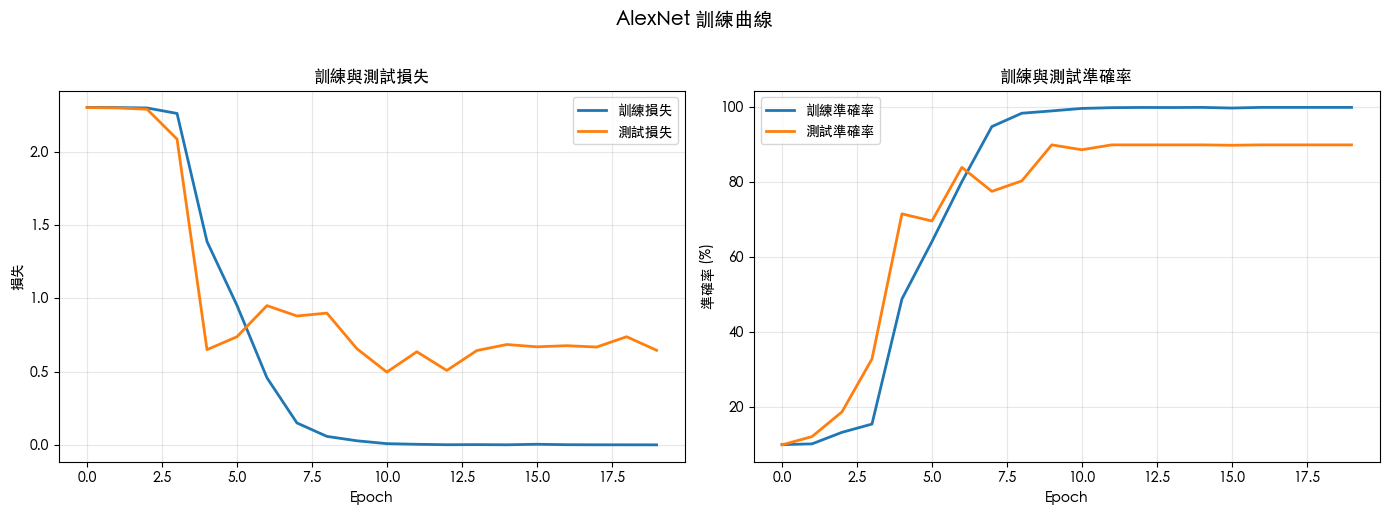

In [15]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 損失曲線
ax = axes[0]
ax.plot(history['train_loss'], label='訓練損失', linewidth=2)
ax.plot(history['test_loss'], label='測試損失', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('損失')
ax.set_title('訓練與測試損失')
ax.legend()
ax.grid(True, alpha=0.3)

# 準確率曲線
ax = axes[1]
ax.plot(history['train_acc'], label='訓練準確率', linewidth=2)
ax.plot(history['test_acc'], label='測試準確率', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('準確率 (%)')
ax.set_title('訓練與測試準確率')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('AlexNet 訓練曲線', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. 視覺化濾波器和特徵圖

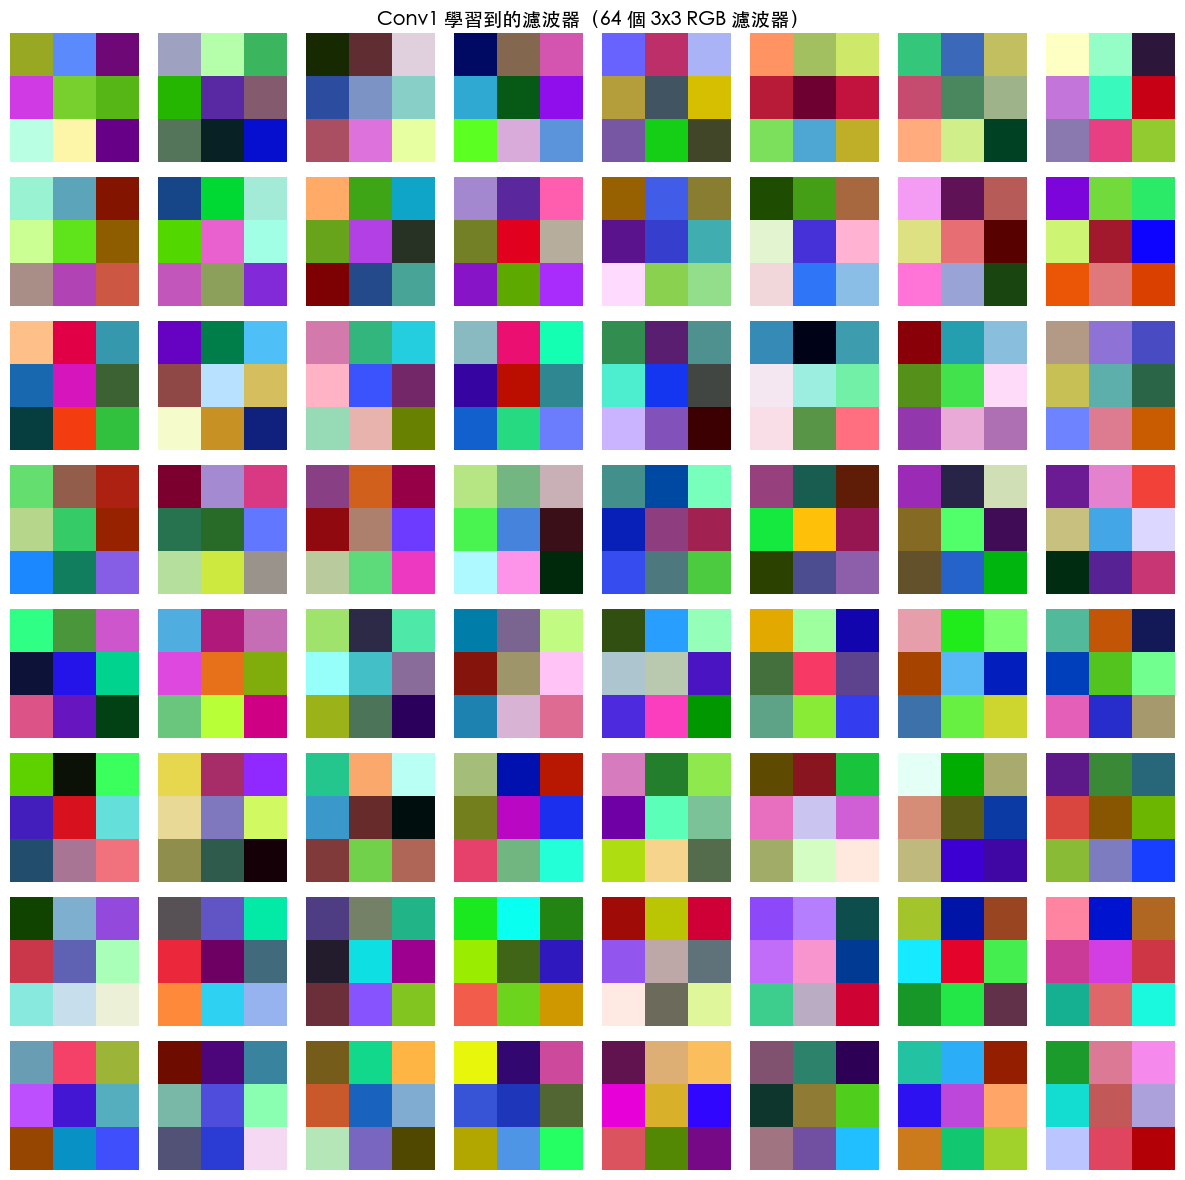

觀察：濾波器學習到不同方向的邊緣和顏色模式


In [16]:
# 載入最佳模型
model.load_state_dict(best_model_state)
model.eval()

# 視覺化第一層卷積濾波器
conv1_weights = model.features[0].weight.data.cpu()

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
axes = axes.flatten()

for i in range(64):
    # 獲取濾波器並正規化
    filt = conv1_weights[i].numpy()
    filt = filt.transpose(1, 2, 0)  # CHW -> HWC
    filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)

    axes[i].imshow(filt)
    axes[i].axis('off')

plt.suptitle('Conv1 學習到的濾波器（64 個 3x3 RGB 濾波器）', fontsize=14)
plt.tight_layout()
plt.show()

print("觀察：濾波器學習到不同方向的邊緣和顏色模式")

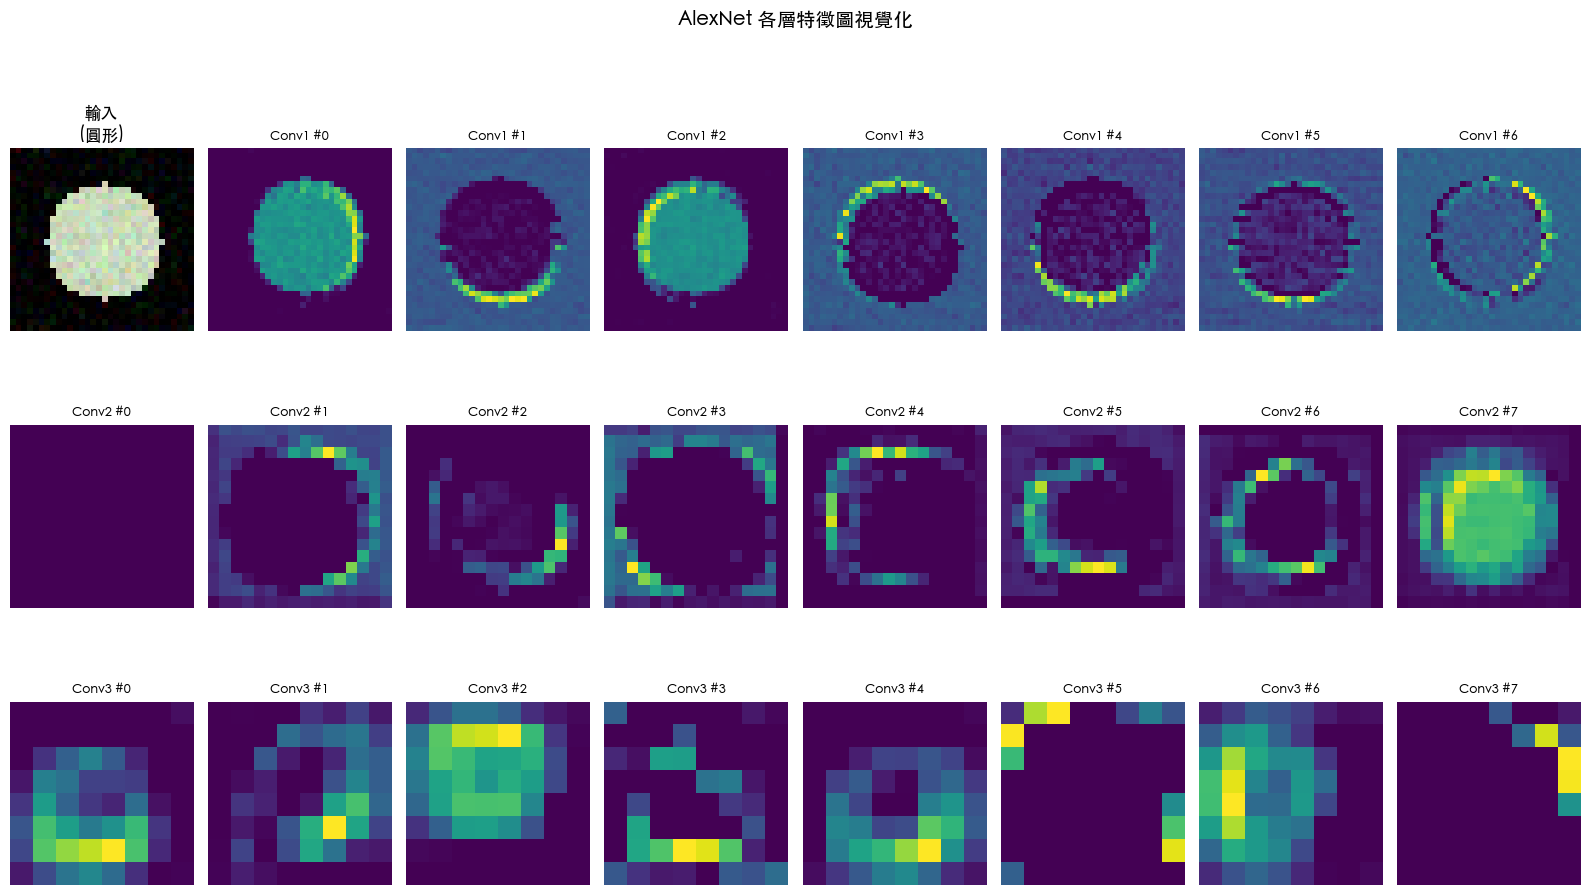

觀察：
- Conv1：檢測邊緣和顏色
- Conv2：組合基本特徵形成更複雜的模式
- Conv3：抽象的高層特徵


In [17]:
# 視覺化特徵圖
def get_feature_maps(model, image, layer_idx):
    """獲取指定層的特徵圖"""
    features = []

    def hook(module, input, output):
        features.append(output)

    # 註冊 hook
    layer = list(model.features.children())[layer_idx]
    handle = layer.register_forward_hook(hook)

    # 前向傳播
    with torch.no_grad():
        _ = model(image)

    handle.remove()
    return features[0]


# 選擇一張測試圖像
test_img, test_label = test_dataset[4]  # 圓形
test_img_batch = test_img.unsqueeze(0).to(device)

# 獲取各層特徵圖
feature_maps = {
    'Conv1': get_feature_maps(model, test_img_batch, 0),
    'Conv2': get_feature_maps(model, test_img_batch, 3),
    'Conv3': get_feature_maps(model, test_img_batch, 6),
}

# 視覺化
fig = plt.figure(figsize=(16, 12))

# 原始圖像
ax = plt.subplot(4, 8, 1)
ax.imshow(test_img.numpy().transpose(1, 2, 0))
ax.set_title(f'輸入\n({train_dataset.class_names[test_label]})')
ax.axis('off')

# Conv1 特徵圖
for i in range(7):
    ax = plt.subplot(4, 8, i + 2)
    ax.imshow(feature_maps['Conv1'][0, i].cpu().numpy(), cmap='viridis')
    ax.set_title(f'Conv1 #{i}', fontsize=9)
    ax.axis('off')

# Conv2 特徵圖
for i in range(8):
    ax = plt.subplot(4, 8, 9 + i)
    ax.imshow(feature_maps['Conv2'][0, i].cpu().numpy(), cmap='viridis')
    ax.set_title(f'Conv2 #{i}', fontsize=9)
    ax.axis('off')

# Conv3 特徵圖
for i in range(8):
    ax = plt.subplot(4, 8, 17 + i)
    ax.imshow(feature_maps['Conv3'][0, i].cpu().numpy(), cmap='viridis')
    ax.set_title(f'Conv3 #{i}', fontsize=9)
    ax.axis('off')

plt.suptitle('AlexNet 各層特徵圖視覺化', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("觀察：")
print("- Conv1：檢測邊緣和顏色")
print("- Conv2：組合基本特徵形成更複雜的模式")
print("- Conv3：抽象的高層特徵")

## 10. 預測視覺化

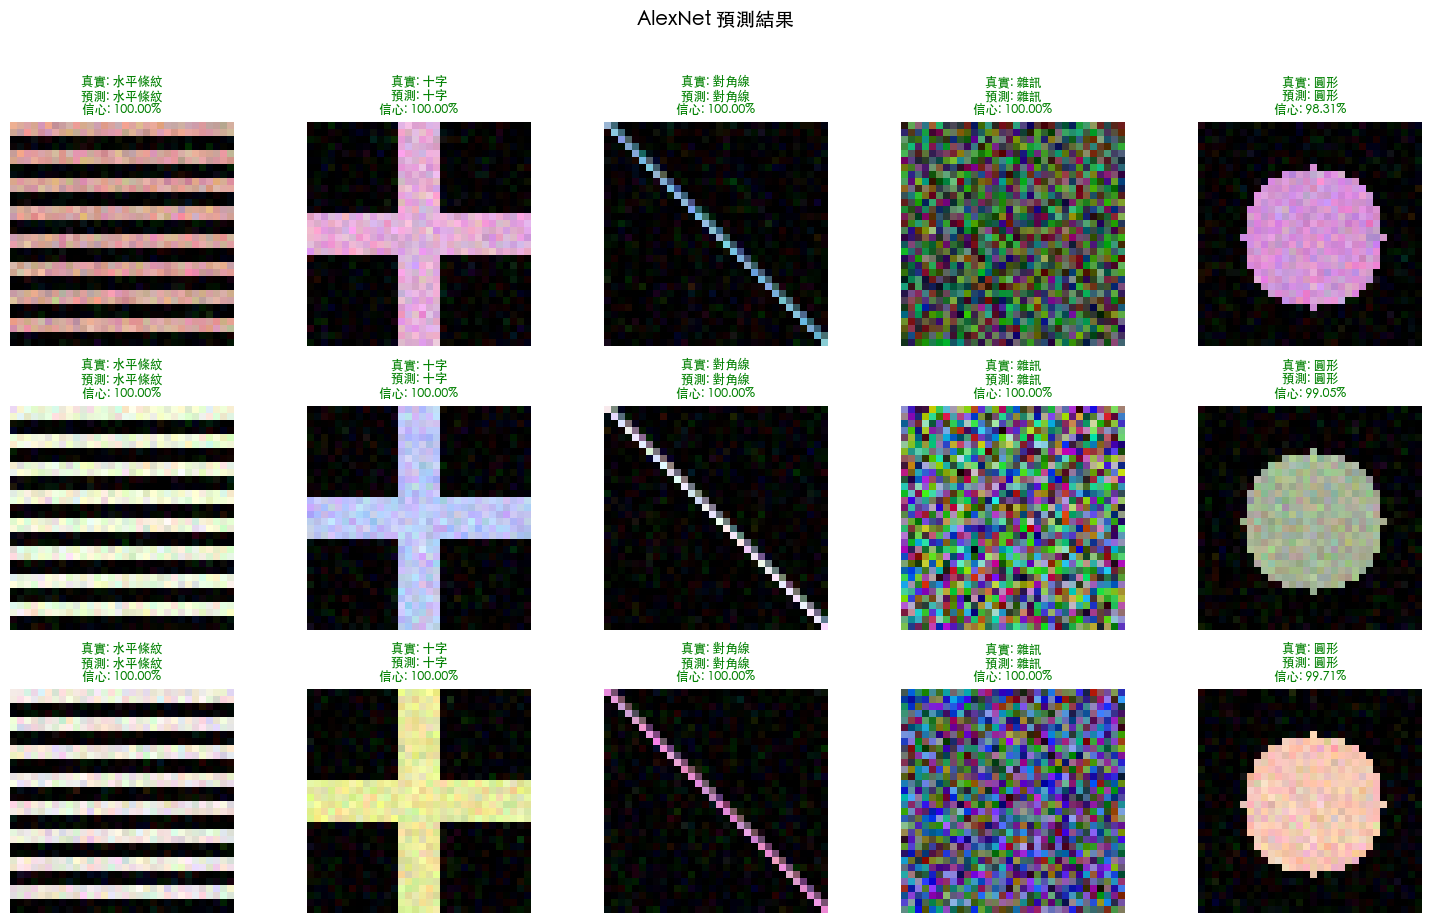


各類別準確率：
  水平條紋    : 100.0%
  垂直條紋    : 0.0%
  對角線     : 100.0%
  棋盤格     : 100.0%
  圓形      : 100.0%
  方形      : 100.0%
  十字      : 100.0%
  三角形     : 100.0%
  雜訊      : 100.0%
  漸層      : 100.0%


In [18]:
# 視覺化預測結果
model.eval()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i in range(15):
    idx = i * (len(test_dataset) // 15)
    img, true_label = test_dataset[idx]

    # 預測
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        probs = F.softmax(output, dim=1)[0]
        pred_label = output.argmax(dim=1).item()

    # 繪製
    row = i // 5
    col = i % 5
    ax = axes[row, col]

    ax.imshow(img.numpy().transpose(1, 2, 0))

    is_correct = pred_label == true_label
    color = 'green' if is_correct else 'red'

    ax.set_title(
        f'真實: {train_dataset.class_names[true_label]}\n'
        f'預測: {train_dataset.class_names[pred_label]}\n'
        f'信心: {probs[pred_label]:.2%}',
        fontsize=9, color=color
    )
    ax.axis('off')

plt.suptitle('AlexNet 預測結果', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 計算混淆矩陣
all_preds = []
all_labels = []

with torch.no_grad():
    for img, label in test_dataset:
        output = model(img.unsqueeze(0).to(device))
        pred = output.argmax(dim=1).item()
        all_preds.append(pred)
        all_labels.append(label)

# 計算每類準確率
print("\n各類別準確率：")
for i in range(10):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        class_acc = (np.array(all_preds)[mask] == i).mean() * 100
        print(f"  {train_dataset.class_names[i]:8s}: {class_acc:.1f}%")

## 11. 關鍵要點總結

### AlexNet 的主要創新（2012）

1. **ReLU 活化函數**
   - 比 Sigmoid/Tanh 訓練快約 6 倍
   - 緩解梯度消失問題

2. **Dropout 正規化**
   - 訓練時隨機丟棄 50% 的神經元
   - 有效防止過擬合

3. **資料增強**
   - 隨機裁剪、翻轉
   - PCA 顏色增強

4. **GPU 加速**
   - 使用 2 個 GTX 580 GPU
   - 使深度網路訓練變得實際可行

### 架構特點

- 5 個卷積層 + 3 個全連接層
- 約 6200 萬參數
- 使用重疊池化
- 局部響應正規化（現已被 BatchNorm 取代）

### 歷史影響

- 贏得 ImageNet 2012（15.3% top-5 錯誤率）
- 重新點燃深度學習研究熱潮
- 啟發後續網路：VGG、GoogLeNet、ResNet

## 論文連結

**ImageNet Classification with Deep Convolutional Neural Networks**

https://papers.nips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html

![論文 QR Code](paper_qrcode.png)